### Model training notebook

In [1]:
# Dataset
from pandas import read_csv, concat
from numpy import sum, unique
from seaborn import histplot
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Sklearn intel extension
from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [7]:
# Read the training data
#training_df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_corr_smote_training_data.csv')
#training_df.drop(columns = ['air_temperature_at_surface [degC]'], inplace=True)
df_1 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv')
df_1.rename(columns = {"UHI Index binned" : "UHI Index"}, inplace = True)
df_2 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df_2.drop(columns = ['means_clusters'], inplace = True)
training_df = concat((df_1, df_2), axis = 0)
training_df.drop_duplicates(subset = training_df.columns[:-1], keep = 'last', inplace = True)

# Read the test data
test_df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_test_data.csv')
test_df.drop(columns = ['means_clusters'], inplace=True)

# Read the submission data
submission_df = read_csv('../data/initial_datasets/Submission_template_UHI2025-v2.csv')

In [10]:
# Separate predictors and responses
X = training_df.drop(columns = ['UHI Index']).values
y = training_df['UHI Index'].values

In [21]:
# Separate predictors and responses
X_test = test_df.values

In [144]:
# Generate array of weights
w = (abs(y - y.mean()))**2
w = w/sum(w)

In [29]:
knnr_1 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 1, 
                            p = 2, 
                            weights = 'distance')
knnr_2 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 2, 
                            p = 2, 
                            weights = 'distance')
knnr_3 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 3, 
                            p = 2, 
                            weights = 'distance')
knnr_4 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 4, 
                            p = 2, 
                            weights = 'distance')
knnr_5 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 5, 
                            p = 2, 
                            weights = 'distance')
estimators = [('knnr_1', knnr_1), 
              ('knnr_2', knnr_2), 
              ('knnr_3', knnr_3), 
              ('knnr_4', knnr_4),
              ('knnr_5', knnr_5)]
model = VotingRegressor(estimators = estimators)
model.fit(X, y)

VotingRegressor(estimators=[('knnr_1',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=1,
                                                 weights='distance')),
                            ('knnr_2',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=2,
                                                 weights='distance')),
                            ('knnr_3',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=3,
                                                 weights='distance')),
                            ('knnr_4',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=4,
                                                 weights='distance')),
                            ('knnr_5',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 weights='distance'))])

In [22]:
"""# Train the Random Forest model on the training data
xgbr = XGBRegressor(nthread = -1, 
                    colsample_bylevel = 0.0041021679312702106,
                    colsample_bynode = 9.496153919454603e-05,
                    colsample_bytree = 0.507766346902615,
                    eta = 0.06846197227002367,
                    gamma = 8.336928029145515e-07,
                    max_depth = 15,
                    min_child_weight = 0.00010584940961770894,
                    reg_alpha = 0.00044107814104277964,
                    reg_lambda = 1.1242717718084416e-08,
                    subsample = 0.6863233496022993,
                    tree_method = 'exact',
                    random_state = 10)"""
                    
model = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 2, 
                            p = 2, 
                            weights = 'distance')

"""rfr = RandomForestRegressor(n_estimators = 256, 
                            criterion = 'poisson',
                            ccp_alpha = 2.9335950946398258e-09, 
                            max_features = 0.7, 
                            max_leaf_nodes = 2011,
                            min_samples_split = 0.00019195196714680176,
                            min_samples_leaf = 0.00011054147285459687, 
                            max_depth = 23,
                            random_state = 10)
estimators = [('xgbr', xgbr), ('knnr', knnr), ('rfr', rfr)]
model = VotingRegressor(estimators = estimators)"""
#model = AdaBoostRegressor(estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance'), 
#                          random_state = 10)
#model.fit(X, y, sample_weight = w)
model.fit(X, y)

KNeighborsRegressor(metric='manhattan', n_jobs=1, n_neighbors=2,
                    weights='distance')

In [197]:
#df_names = read_csv('../data/final_datasets/raw_datasets/raw_reduced_training_data.csv')
corr = training_df.corr(method = 'spearman')

columns_correlations_importances = []

for column, correlation, importance in zip(training_df.columns[:-1], corr['UHI Index'].values[:-1], model.feature_importances_):
    columns_correlations_importances.append([column, correlation, importance])
    
sorted_list = sorted(columns_correlations_importances, key = lambda x: x[2], reverse = False)

In [200]:
sorted_list

[['51', -0.20005463228318549, 0.0021816611019386516],
 ['32', 0.061826834464204526, 0.002591142979941201],
 ['54', -0.15649582131022596, 0.0027549237688456636],
 ['38', 0.0784765471152299, 0.0030139304061379737],
 ['11', -0.16602502099113825, 0.0030411497943025325],
 ['41', -0.2189762059906151, 0.0030442209168506894],
 ['33', 0.03129566643779042, 0.003164212527988888],
 ['43', -0.17744463392135307, 0.003167608703581162],
 ['31', 0.0693321797763717, 0.0032374351302654845],
 ['2', 0.32821997898947913, 0.003300652661961525],
 ['47', -0.07085075439914174, 0.003407370290224194],
 ['9', -0.15098557857928666, 0.0034077141995664047],
 ['48', -0.05466371128557382, 0.0035066170784968155],
 ['42', -0.19232517949581138, 0.003528529172209123],
 ['30', 0.07732294358748161, 0.0036985635011713065],
 ['52', -0.20019464909248277, 0.0037054452720515496],
 ['23', -0.13925761177155832, 0.0037831335951010255],
 ['50', -0.22167094252334726, 0.003867265506994517],
 ['evi_median_res100', -0.17787421787852986, 

In [201]:
### Iterate over the different thresholds to test which set of dropped features gets the greatest training R^2
for th in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]:
    # Set the cumulative sum of importances to 0
    sum = 0.0
    for i, row in enumerate(sorted_list):
        sum = sum + 100.0*row[2]
        if sum >= th:
            i_lim = i
            break

    # Set columns to roule out
    cols = []
    for row in sorted_list[:i_lim]:
        cols.append(row[0])
        
    # Set predictors to train the model
    X_tmp = training_df.drop(columns = cols + ['UHI Index'])
    
    # Split in training and test data
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(X_tmp, y, random_state=0)
    
    # Train the Random Forest model on the training data
    model_tmp = RandomForestRegressor(n_estimators = 256, 
                                    criterion = 'poisson',
                                    ccp_alpha = 2.9335950946398258e-09, 
                                    max_features = 0.7, 
                                    max_leaf_nodes = 2011,
                                    min_samples_split = 0.00019195196714680176,
                                    min_samples_leaf = 0.00011054147285459687, 
                                    max_depth = 23,
                                    random_state = 10)
    
    # Fit the model
    model_tmp.fit(X_train_tmp, y_train_tmp)
    
    # Make predictions on the training data
    train_predictions_tmp = model_tmp.predict(X_train_tmp)
    
    # Make predictions on the test data
    test_predictions_tmp = model_tmp.predict(X_test_tmp)
    
    # Calculate R-squared score for in-sample and test predictions
    train_r_squared = r2_score(y_train_tmp.tolist(), train_predictions_tmp)
    test_r_squared = r2_score(y_test_tmp.tolist(), test_predictions_tmp)
    
    print("Number of columns to drop {}. R^2 generated after dropping variables: Training {} | Test {}.".format(i_lim, train_r_squared, test_r_squared))

Number of columns to drop 3. R^2 generated after dropping variables: Training 0.9887845250233145 | Test 0.956434685825971.
Number of columns to drop 7. R^2 generated after dropping variables: Training 0.9887685871035639 | Test 0.956686506245836.
Number of columns to drop 10. R^2 generated after dropping variables: Training 0.9887125673485982 | Test 0.9567266511407347.
Number of columns to drop 13. R^2 generated after dropping variables: Training 0.9887543665196352 | Test 0.9570196356721905.
Number of columns to drop 15. R^2 generated after dropping variables: Training 0.9887071588207901 | Test 0.9566249315583074.
Number of columns to drop 18. R^2 generated after dropping variables: Training 0.9887589561932527 | Test 0.9569659606633234.
Number of columns to drop 20. R^2 generated after dropping variables: Training 0.9886414784759011 | Test 0.9569233939381787.
Number of columns to drop 23. R^2 generated after dropping variables: Training 0.9886938427853955 | Test 0.9573796547627786.
Numb

In [ ]:
for row in sorted_list[:28]:
    print(row[0])

51
32
54
38
11
41
33
43
31
2
47
9
48
42
30
52
23
50
evi_median_res100
B6_median_res250
B6_median_res100
siwsi_median_res250
45
B2_median_res500
w_median_res100
B8A_median_res250
B8_median_res250
53


In [30]:
# Make predictions on the training data
insample_predictions = model.predict(X)

In [31]:
# calculate R-squared score for in-sample predictions
y_train = y.tolist()
r_squared = r2_score(y_train, insample_predictions)
print(r_squared)

1.0


- Submission 1: (RFR - full dataset) training $R^2 = 0.9863$
- Submission 2: (RFR - reduced dataset) training $R^2 = 0.9822$
- Submission 3: (RFR - reduced SMOTE dataset) training $R^2 = 0.9921$
- Submission 4: (RFR - reduced SMOTE dataset - n_stimators = 50) training $R^2 = 0.9915$
- Submission 5: (RFR - reduced dataset - n_stimators = 50) training $R^2 = 0.9811$
- Submission 6: (RFR - reduced dataset - n_estimators = 128, ccp_alpha = 5.0e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 8) training $R^2 = 0.3278$
- Submission 7: (RFR - reduced SMOTE dataset - n_estimators = 128, ccp_alpha = 5.0e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 8) training $R^2 = 0.6184$
- Submission 8: (RFR - complete reduced dataset - n_estimators = 128, ccp_alpha = 2.5e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 11) training $R^2 = 0.6834$
- Submission 9: (RFR - complete reduced SMOTE dataset - n_estimators = 128, ccp_alpha = 2.5e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 12) training $R^2 = 0.8516$
- Submission 10: (RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 1.3809434469711727e-07, max_features = 0.8, max_leaf_nodes = 176, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 15) training $R^2 = 0.9215$
- Submission 11: (RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 2241, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 25) training $R^2 = 0.9730$
- Submission 12: (XGBR - complete reduced 98imp dataset - nthread = -1, subsample = 0.5) training $R^2 = 0.9798$
- Submission 13: (square weighted RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 2241, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 25) training $R^2 = 0.9596$
- Submission 14: (cubic weighted RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 2241, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 25) training $R^2 = 0.9397$
- Submission 15: (XGBR - complete reduced 98imp dataset - nthread = -1, colsample_bylevel = 0.27089875569868677, colsample_bynode = 0.00023871262162442934, colsample_bytree = 0.2521310852858073, eta = 0.16984948183848828, gamma = 4.936495008750438e-07, max_depth = 9, min_child_weight = 1.1130829945563475e-06, reg_alpha = 0.00027764020436691245, reg_lambda = 0.11543156340963502, subsample = 0.6725418424266979, tree_method = 'auto') training $R^2 = 0.9893$
- Submission 16: (KNNR - complete reduced 98imp dataset - weights = 'distance', n_neighbors = 5, leaf_size = 356, algorithm = 'kd_tree') training $R^2 = 1.0$
- Submission 17: (KNNR - complete reduced oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 18: (KNNR - complete reduced oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 7, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 19: (XGBR - complete reduced oversampled 98imp dataset - nthread = -1, colsample_bylevel = 0.27089875569868677, colsample_bynode = 0.00023871262162442934, colsample_bytree = 0.2521310852858073,
eta = 0.16984948183848828, gamma = 4.936495008750438e-07, max_depth = 9, min_child_weight = 1.1130829945563475e-06, reg_alpha = 0.00027764020436691245, reg_lambda = 0.11543156340963502, subsample = 0.6725418424266979, tree_method = 'auto') training $R^2 = 0.9732$
- Submission 20: (KNNR - complete reduced double oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 21: (KNNR - complete reduced 1sigma oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 22: (RFR - complete dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 1900, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 20, random_state = 10) training $R^2 = 0.9739$
- Submission 23: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 24: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 5, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 25: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 6, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 26: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 27: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 28: (KNNR - complete half sigma oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 29: (KNNR - complete reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 30: (KNNR - complete reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 31: (KNNR - complete reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 32: (KNNR - complete half sigma oversampled reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 7, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 33: (KNNR - complete half sigma oversampled reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 6, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 34: (KNNR - complete half sigma oversampled reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 5, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 35: (KNNR - complete half sigma oversampled reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 36: (KNNR - complete half sigma oversampled reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 37: (KNNR - complete half sigma oversampled reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 38: (KNNR - complete reduced PCA dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 39: (XGBR - complete reduced dataset - nthread = -1, colsample_bylevel = 0.00025590970573705074, colsample_bynode = 0.0016125310507609189, colsample_bytree = 0.7224831748725747,
 eta = 0.18997582778109562, gamma = 4.495813828450373e-06, max_depth = 12, min_child_weight = 8.796462044636197e-05, reg_alpha = 1.3618213880575843e-07, reg_lambda = 2.0516109493758132e-07,
 subsample = 0.52161392755372, tree_method = 'auto') training $R^2 = 0.9920$
- Submission 40: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 10, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 41: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 9, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 42: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 8, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 43: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 7, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 44: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 6, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 45: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 5, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 46: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 47: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 48: (KNNR - complete reduced oversampled2 dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 49: (KNNR - complete maxreduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 50: (KNNR - complete maxreduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 51: (KNNR - complete maxreduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 10, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 52: (KNNR - complete maxreduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 50, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 53: (ABR - complete reduced dataset - estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance')) training $R^2 = 0.9999$
- Submission 54: (XGBR - complete maxreduced dataset - colsample_bylevel = 0.26039175857141017, colsample_bynode = 0.0026795271301607616, colsample_bytree = 0.17273120612209947, eta = 0.23140004684157492, gamma = 3.2666575813880865e-06, max_depth = 12, min_child_weight = 1.710210297185527, reg_alpha = 2.8399331769460818e-06, reg_lambda = 0.38787583265517744, subsample = 0.9850474055600175, tree_method = 'exact')  training $R^2 = 0.9965$
- Submission 55: (ABR - complete reduced dataset - estimator = DecisionTreeRegressor(random_state = 0, ccp_alpha = 5.93279137e-20, criterion = 'squared_error', max_features = 0.8, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, splitter = 'best')) training $R^2 = 0.9933$
- Submission 56: (ABR - complete reduced dataset - estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance'), n_estimators = 300) training $R^2 = 0.9998$
- Submission 57: (KNNR - complete interactions reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 58: (KNNR - complete interactions reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 59: (KNNR - complete interactions reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 60: (KNNR - complete reduced smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 61: (KNNR - complete reduced smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 62: (XGBR - complete reduced oversampled2 dataset - colsample_bylevel = 0.5698708055756097,
 colsample_bynode = 6.961332257179578e-05, colsample_bytree = 0.7788176842566492, eta = 0.09364657790950402, gamma = 1.1781361652396031e-07, max_depth = 15, min_child_weight = 8.335064201958971, reg_alpha = 1.7282800046371056e-07, reg_lambda = 0.18565485704166115, subsample = 0.460506422932427, tree_method = 'hist') training $R^2 = 0.9550$
- Submission 63: (ABR - complete reduced smote dataset - estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance')) training $R^2 = 1.0$
- Submission 64: (RFR - complete reduced smote dataset - n_estimators = 256, criterion = 'poisson', ccp_alpha = 2.9335950946398258e-09, max_features = 0.7, max_leaf_nodes = 2011, min_samples_split = 0.00019195196714680176, min_samples_leaf = 0.00011054147285459687, max_depth = 23) training $R^2 = 0.9953$
- Submission 65: (XGBR - complete reduced smote dataset - colsample_bylevel = 0.0041021679312702106, colsample_bynode = 9.496153919454603e-05, colsample_bytree = 0.507766346902615, eta = 0.06846197227002367,
gamma = 8.336928029145515e-07, max_depth = 15, min_child_weight = 0.00010584940961770894, reg_alpha = 0.00044107814104277964, reg_lambda = 1.1242717718084416e-08, subsample = 0.6863233496022993, tree_method = 'exact') training $R^2 = 0.9992$
- Submission 66: (VR - complete reduced smote dataset - best models ('xgbr', xgbr), ('knnr', knnr), ('rfr', rfr)) training $R^2 = 0.9991$
- Submission 67: (VR - complete dataset - best smote models ('xgbr', xgbr), ('knnr', knnr), ('rfr', rfr)) training $R^2 = 0.9974$
- Submission 68: (VR - complete reduced dataset - best smote models ('xgbr', xgbr), ('knnr', knnr), ('rfr', rfr)) training $R^2 = 0.9974$
- Submission 69: (VR - complete reduced dataset - best reduced models ('xgbr', xgbr), ('knnr', knnr), ('rfr', rfr)) training $R^2 = 0.9972$
- Submission 70: (VR - complete reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4)) training $R^2 = 1.0$
- Submission 71: (VR - complete reduced smote dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4)) training $R^2 = 1.0$
- Submission 72: (KNNR - complete reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 73: (VR - complete reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4)) training $R^2 = 1.0$
- Submission 74: (RFR - complete reduced dataset - n_estimators = 256, criterion = 'poisson', ccp_alpha = 2.9335950946398258e-09, max_features = 0.7, max_leaf_nodes = 2011, min_samples_split = 0.00019195196714680176, min_samples_leaf = 0.00011054147285459687, max_depth = 23) training $R^2 = 0.9878$
- Submission 75: (VR - complete reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)) training $R^2 = 1.0$
- Submission 76: (VR - complete reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5), ('knnr_6', knnr_6)) training $R^2 = 1.0$
- Submission 77: (VR - complete reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)) training $R^2 = 1.0$
- Submission 78: (VR - complete reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5), ('knnr_6', knnr_6)) training $R^2 = 1.0$
- Submission 79: (VR - complete dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)) training $R^2 = 1.0$
- Submission 80: (VR - complete dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5), ('knnr_6', knnr_6)) training $R^2 = 1.0$
- Submission 81: (VR - complete reduced smote dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5), ('knnr_6', knnr_6)) training $R^2 = 1.0$
- Submission 82: (VR - complete reduced smote dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)) training $R^2 = 1.0$
- Submission 83: (VR - complete interactions reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)) training $R^2 = 1.0$
- Submission 84: (VR - complete interactions reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)) training $R^2 = 1.0$
- Submission 85: (VR - complete interactions reduced dataset - best reduced models ('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4)) training $R^2 = 1.0$
- Submission 86: (ABR - complete interactions reduced dataset - estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance')) training $R^2 = 1.0$
- Submission 87: (KNNR - complete interactions reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 88: (KNNR - complete interactions reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 89: (KNNR - complete interactions reduced smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 90: (KNNR - complete interactions reduced smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 91: (KNNR - complete interactions reduced smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 92: (ABR - complete interactions reduced smote dataset - estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance')) training $R^2 = 1.0$
- Submission 93: (VR - complete interactions reduced smote dataset - estimators = [('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)]) training $R^2 = 1.0$
- Submission 94: (VR - complete interactions reduced smote dataset - estimators = [('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4)]) training $R^2 = 1.0$
- Submission 95: (KNNR - complete reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 96: (KNNR - complete reduced dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 97: (KNNR - complete interactions reduced oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 6, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 98: (KNNR - complete interactions reduced oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 5, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 99: (KNNR - complete interactions reduced oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 100: (KNNR - complete interactions reduced oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 101: (KNNR - complete interactions reduced oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 102: (KNNR - complete reduced corr dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 103: (KNNR - complete reduced corr dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 104: (ABR - complete reduced corr dataset - estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance')) training $R^2 = 0.9999$
- Submission 105: (VR - complete reduced corr dataset - estimators = [('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)]) training $R^2 = 1.0$
- Submission 106: (VR - complete reduced corr dataset - estimators = [('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4)]) training $R^2 = 1.0$
- Submission 107: (VR - complete reduced corr dataset - estimators = [('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5), ('knnr_6', knnr_6)]) training $R^2 = 1.0$
- Submission 108: (RFR - complete reduced corr dataset - n_estimators = 256, criterion = 'poisson', ccp_alpha = 5.932791367786729e-20, max_features = 0.7, max_leaf_nodes = 2205, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 27) training $R^2 = 0.9719$
- Submission 109: (KNNR - complete reduced corr smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 110: (KNNR - complete reduced smote + no smote dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 111: (KNNR - complete reduced smote + no smote no duplicates dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 112: (VR - complete reduced smote + no smote no duplicates dataset - estimators = [('knnr_1', knnr_1), ('knnr_2', knnr_2), ('knnr_3', knnr_3), ('knnr_4', knnr_4), ('knnr_5', knnr_5)]) training $R^2 = 1.0$

In [32]:
# Make predictions on the test data
predictions = model.predict(X_test)

<Axes: ylabel='Count'>

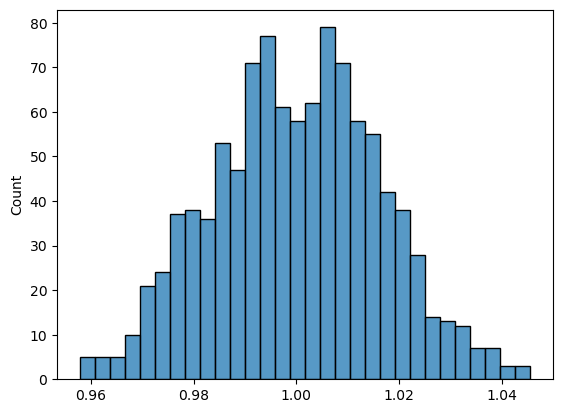

In [33]:
histplot(predictions, bins=30)

In [34]:
# Replace predictions of test data on submission dataset
submission_df['UHI Index'] = predictions

In [35]:
# Save the submission dataset
submission_df.to_csv('../data/submissions/submission-v112.csv', index = False)